## This notebook is used to explore SHAP values explainable library for Python (Make sure you use 11.3 LTS)

In [0]:
pip install shap

Python interpreter will be restarted.
  Using cached shap-0.47.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (994 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl (20 kB)
  Using cached numba-0.60.0-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.5 MB)
  Using cached llvmlite-0.43.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (43.9 MB)
  Using cached numpy-1.22.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.3
    Not uninstalling numpy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-5a8ddeaf-31e7-4f8d-aa6a-2821ac4230d1
    Can't uninstall 'numpy'. No files were found to uninstall.
Python 

In [0]:
pip install typing_extensions --upgrade

Python interpreter will be restarted.
  Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.2
    Not uninstalling typing-extensions at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-5a8ddeaf-31e7-4f8d-aa6a-2821ac4230d1
    Can't uninstall 'typing-extensions'. No files were found to uninstall.
Python interpreter will be restarted.


In [0]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import pyspark.sql.functions as F
from delta.tables import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
write_path = 'dbfs:/tmp/reproducible_ml_uofl/diab_readmit_uofl.delta'
diabetes_delta = spark.read.format('delta').load(write_path).toPandas()
diabetes_delta

,patient_nbr,time_in_hospital,num_procedures,num_lab_procedures,num_medications,number_outpatient,number_inpatient,number_emergency,number_diagnoses,gender_cd,DiabetesMedication,readmit_flag,race_cd
0,8222157,1,0,41,1,0,0,0,1,1,0,0,White
1,55629189,3,0,59,18,0,0,0,9,1,1,0,White
2,86047875,2,5,11,13,2,1,0,6,1,1,0,AfrAmr
3,82442376,2,1,44,16,0,0,0,7,0,1,0,White
4,42519267,1,0,51,8,0,0,0,5,0,1,0,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,3,0,51,16,0,0,0,9,0,1,0,AfrAmr
101762,74694222,5,3,33,18,0,1,0,9,1,1,0,AfrAmr
101763,41088789,1,0,53,9,1,0,0,13,0,1,0,White
101764,31693671,10,2,45,21,0,1,0,9,1,1,0,White


In [0]:
## Split the data into training and test sets. (0.75, 0.25) split.
seed = 1834559827
train, test = train_test_split(diabetes_delta, train_size=0.75, random_state=seed)

## The target column is "quality" which is a scalar from [3, 9]
X_train = train.drop(['patient_nbr','readmit_flag','race_cd'], axis=1)
X_test = test.drop(['patient_nbr','readmit_flag','race_cd'], axis=1)
Y_train = train[['readmit_flag']]
Y_test = test[['readmit_flag']]

In [0]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=6, random_state=0, n_estimators=10)
rf.fit(X_train, Y_train.values.ravel())  

Out[4]: RandomForestClassifier(max_depth=6, n_estimators=10, random_state=0)

In [0]:
from sklearn.metrics import roc_auc_score, roc_curve

print(f'Train ROC AUC Score: {roc_auc_score(Y_train, rf.predict_proba(X_train)[:, 1])}')
print(f'Test ROC AUC  Score: {roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1])}')

Train ROC AUC Score: 0.6445396186213521
Test ROC AUC  Score: 0.6301422269142684


In [0]:
# Get the predictions and put them with the test data.
X_output = X_test.copy()
X_output.loc[:,'predict'] = np.round(rf.predict_proba(X_output)[:, 1],2)

# Sort by highest to lowest predicted probability 
X_output_sorted= X_output.sort_values('predict',ascending=False)

In [0]:
import shap
X_test_new = X_output_sorted.drop(['predict'], axis=1)
wfall_exapliner = shap.Explainer(rf, X_test_new)
shap_values_waterfall = wfall_exapliner(X_test_new)


 98%|===================| 49778/50884 [00:24<00:00]       

In [0]:
print(wfall_exapliner.expected_value[1])

0.11572753297866409


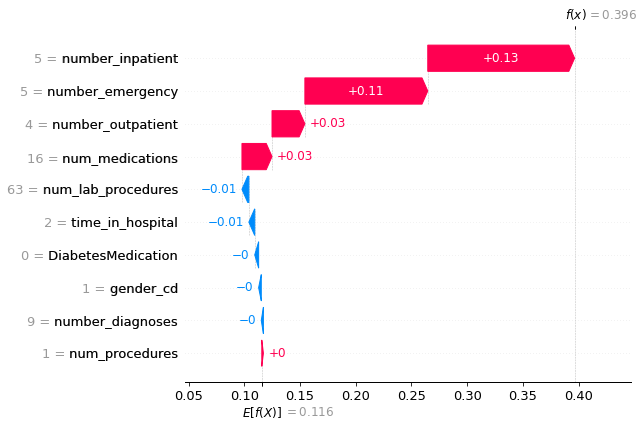

In [0]:
shap.plots.waterfall(shap_values_waterfall[99][:,1], max_display=20)

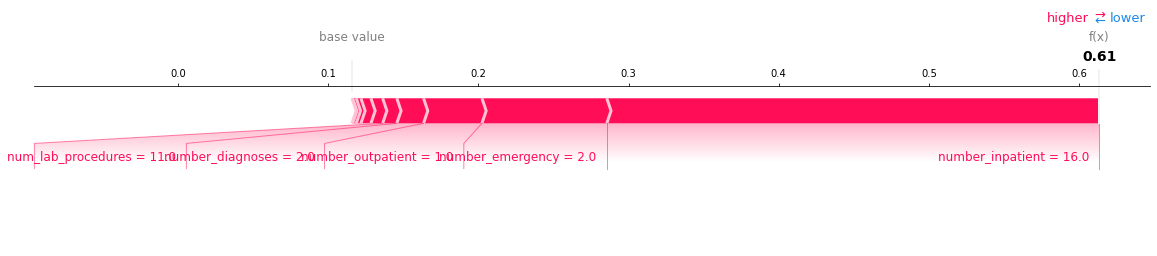

In [0]:
shap.plots.force(shap_values_waterfall[0][:,1], matplotlib=True)

In [0]:
column_names = X_test_new.columns.values.tolist()
column_names

Out[11]: ['time_in_hospital',
 'num_procedures',
 'num_lab_procedures',
 'num_medications',
 'number_outpatient',
 'number_inpatient',
 'number_emergency',
 'number_diagnoses',
 'gender_cd',
 'DiabetesMedication']

In [0]:
shap_values_waterfall[0][:,1]

Out[12]: .values =
array([0.00666443, 0.00309662, 0.00943733, 0.00780598, 0.03889042,
       0.32812594, 0.08317364, 0.01780275, 0.00236608, 0.00051133])

.base_values =
0.11572753297866409

.data =
array([ 2,  1, 11, 14,  1, 16,  2,  2,  1,  1], dtype=int32)